In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (43584, 75)
Test Shape: (11016, 74)


# EDA

In [5]:
train.head()

,Id,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,...,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
0,M00001_P00053,P00053,Pedro Gavi,36,Spanish,Spain,1,Goalkeeper,191,80,...,50.8,0.0,38.6,28.6,31.4,65.4,0,0,67,0
1,M00001_P00054,P00054,Gavi Morata,27,Spanish,Spain,2,Goalkeeper,190,75,...,55.6,0.0,35.7,29.8,46.2,47.8,0,0,392,0
2,M00001_P00056,P00056,Pedro Torres,24,Spanish,Spain,4,Defender,176,78,...,70.5,6.4,52.7,31.3,68.3,59.2,0,0,324,0
3,M00001_P00058,P00058,Rodri Laporte,27,Spanish,Spain,6,Defender,188,80,...,85.6,6.4,48.7,15.3,61.8,55.1,0,1,264,0
4,M00001_P00060,P00060,Ferran Pau,35,Spanish,Spain,8,Defender,179,72,...,37.5,0.0,47.3,34.3,45.3,44.3,0,0,167,0


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43584 entries, 0 to 43583
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        43584 non-null  object 
 1   player_id                 43584 non-null  object 
 2   player_name               43584 non-null  object 
 3   age                       43584 non-null  int64  
 4   nationality               43584 non-null  object 
 5   team                      43584 non-null  object 
 6   jersey_number             43584 non-null  int64  
 7   position                  43584 non-null  object 
 8   height_cm                 43584 non-null  int64  
 9   weight_kg                 43584 non-null  int64  
 10  preferred_foot            43584 non-null  object 
 11  club_name                 43584 non-null  object 
 12  market_value_eur          43584 non-null  int64  
 13  match_id                  43584 non-null  object 
 14  match_

In [7]:
categorical_cols = train.select_dtypes(include='object').columns

numerical_cols = train.select_dtypes(exclude='object').columns

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 15
Numerical: 60


In [8]:
train.columns

Index(['Id', 'player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_s

In [9]:
train.isnull().sum().sum()



np.int64(0)

In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,43584.0,2.641465e+01,4.036415e+00,17.00,24.00,26.00,2.900000e+01,3.900000e+01
jersey_number,43584.0,1.347221e+01,7.482398e+00,1.00,7.00,13.00,2.000000e+01,2.600000e+01
height_cm,43584.0,1.815828e+02,6.332509e+00,163.00,177.00,182.00,1.860000e+02,2.000000e+02
weight_kg,43584.0,7.581424e+01,3.910184e+00,65.00,73.00,76.00,7.800000e+01,8.500000e+01
market_value_eur,43584.0,2.062389e+07,2.752584e+07,528822.00,4611388.00,10428093.00,2.466088e+07,2.000000e+08
goals_team,43584.0,1.330213e+00,1.147894e+00,0.00,0.00,1.00,2.000000e+00,7.000000e+00
goals_opponent,43584.0,1.330396e+00,1.147741e+00,0.00,0.00,1.00,2.000000e+00,7.000000e+00
minutes_played,43584.0,3.595909e+01,3.639900e+01,0.00,0.00,24.00,7.500000e+01,9.000000e+01
goals,43584.0,5.541024e-02,2.517034e-01,0.00,0.00,0.00,0.000000e+00,4.000000e+00
assists,43584.0,5.194567e-02,2.379846e-01,0.00,0.00,0.00,0.000000e+00,3.000000e+00


In [12]:
train.describe(include='O').T

,count,unique,top,freq
Id,43584,43584,M00001_P00053,1
player_id,43584,998,P00939,66
player_name,43584,995,Pierre-Emile Christensen,86
nationality,43584,48,Jamaican,1416
team,43584,48,Jamaica,1416
position,43584,4,Defender,15099
preferred_foot,43584,2,Right,32363
club_name,43584,122,Gor Mahia,714
match_id,43584,1050,M00896,50
match_date,43584,51,2026-06-30,1254


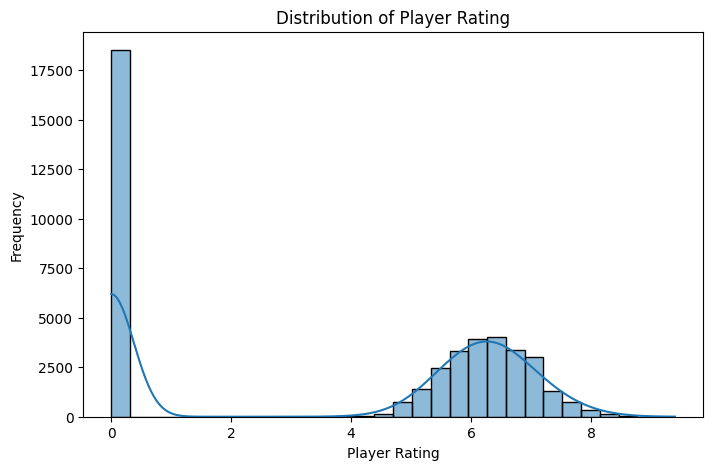

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(train["player_rating"], bins=30, kde=True)

plt.title("Distribution of Player Rating")
plt.xlabel("Player Rating")
plt.ylabel("Frequency")

plt.show()

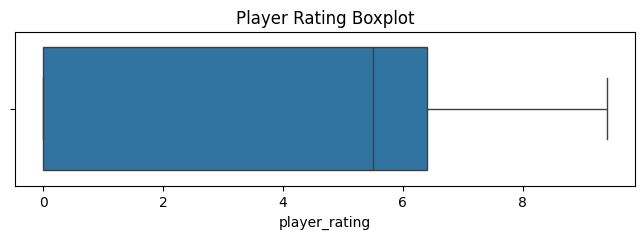

In [14]:
plt.figure(figsize=(8,2))

sns.boxplot(x=train["player_rating"])

plt.title("Player Rating Boxplot")

plt.show()

In [15]:
train.loc[train["player_rating"] == 0, "minutes_played"].describe()

count    18524.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: minutes_played, dtype: float64

### Target Variable Distribution

The distribution of the target variable (`player_rating`) shows two distinct groups. A large number of observations have a rating of **0**, while the remaining ratings are mainly concentrated between **5** and **8**. Therefore, the target variable is **not normally distributed**.

The boxplot indicates that the ratings fall within the expected range (0–9.4) and does not reveal any unusual outliers.

To investigate the large number of zero ratings, the `minutes_played` feature was examined for all players with `player_rating = 0`. The analysis showed that **every player with a zero rating also had `minutes_played = 0`**, indicating that these players did not participate in the match.

This suggests that a rating of zero represents **non-participation rather than poor performance**. Therefore, these observations are considered valid records and will be retained during model development.

In [16]:
corr = train.corr(numeric_only=True)["player_rating"].sort_values(ascending=False)

corr.head(15)

player_rating          1.000000
performance_score      0.996661
top_speed_kmh          0.979691
distance_covered_km    0.837534
minutes_played         0.837339
sprint_distance_km     0.821266
accelerations          0.799028
decelerations          0.794962
total_passes           0.745521
successful_passes      0.726532
possession_impact      0.623876
recoveries             0.604887
defensive_actions      0.567453
stamina_score          0.557274
aerial_duels_won       0.535284
Name: player_rating, dtype: float64

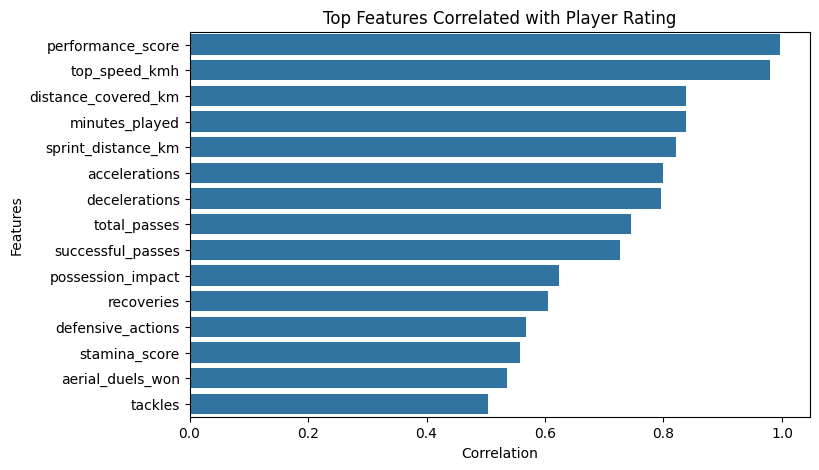

In [17]:
top_corr = corr.drop("player_rating").head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=top_corr.values, y=top_corr.index)

plt.title("Top Features Correlated with Player Rating")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

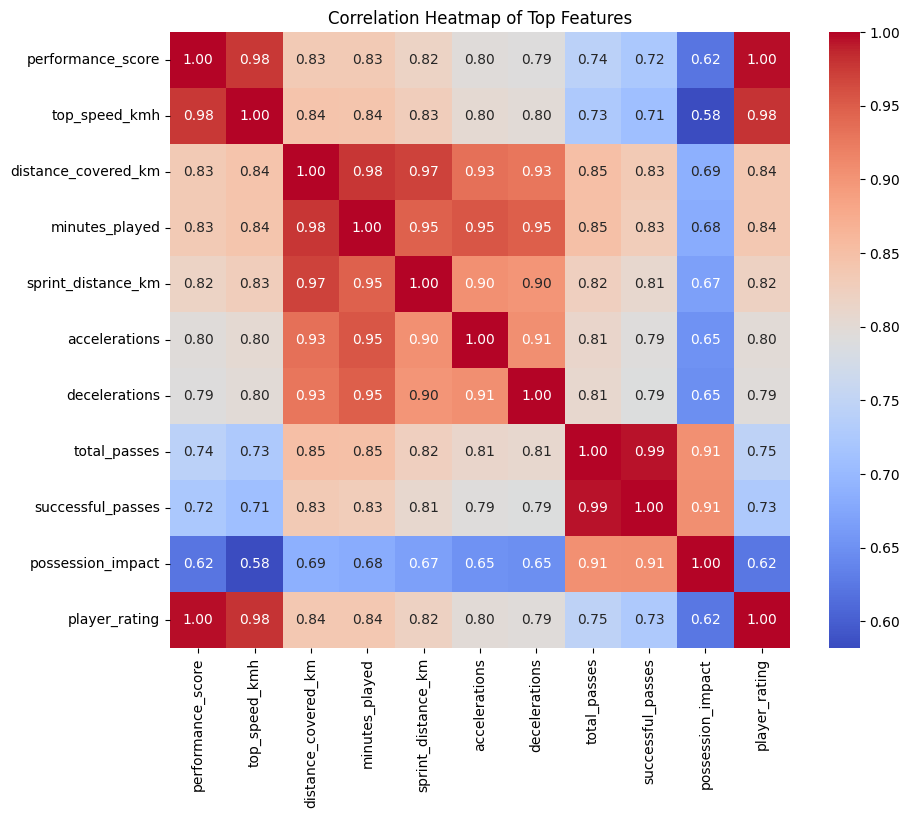

In [18]:
top_features = corr.drop("player_rating").head(10).index.tolist()

heatmap_cols = top_features + ["player_rating"]

plt.figure(figsize=(10,8))

sns.heatmap(
    train[heatmap_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Features")
plt.show()

### Correlation Analysis

A correlation analysis was conducted to identify the numerical features that have the strongest relationship with the target variable (`player_rating`).

The analysis shows that several physical performance and match activity metrics are highly correlated with player ratings. The strongest positive correlations include:

- `performance_score` (0.997)
- `top_speed_kmh` (0.980)
- `distance_covered_km` (0.838)
- `minutes_played` (0.837)
- `sprint_distance_km` (0.821)
- `accelerations` (0.799)
- `decelerations` (0.795)
- `total_passes` (0.746)
- `successful_passes` (0.727)
- `possession_impact` (0.624)

The heatmap also reveals strong correlations among several predictor variables. For example:

- `performance_score` and `top_speed_kmh` are highly correlated.
- `distance_covered_km`, `minutes_played`, and `sprint_distance_km` exhibit strong positive relationships.
- `total_passes` and `successful_passes` are almost perfectly correlated, indicating potential multicollinearity.

In addition, `performance_score` shows an exceptionally high correlation with the target variable (0.997). This feature will be examined further during the feature selection stage to determine whether it represents engineered information that could introduce target leakage.

In [19]:
features = [
    "performance_score",
    "minutes_played",
    "distance_covered_km",
    "top_speed_kmh",
    "total_passes",
    "successful_passes",
    "accelerations"
]

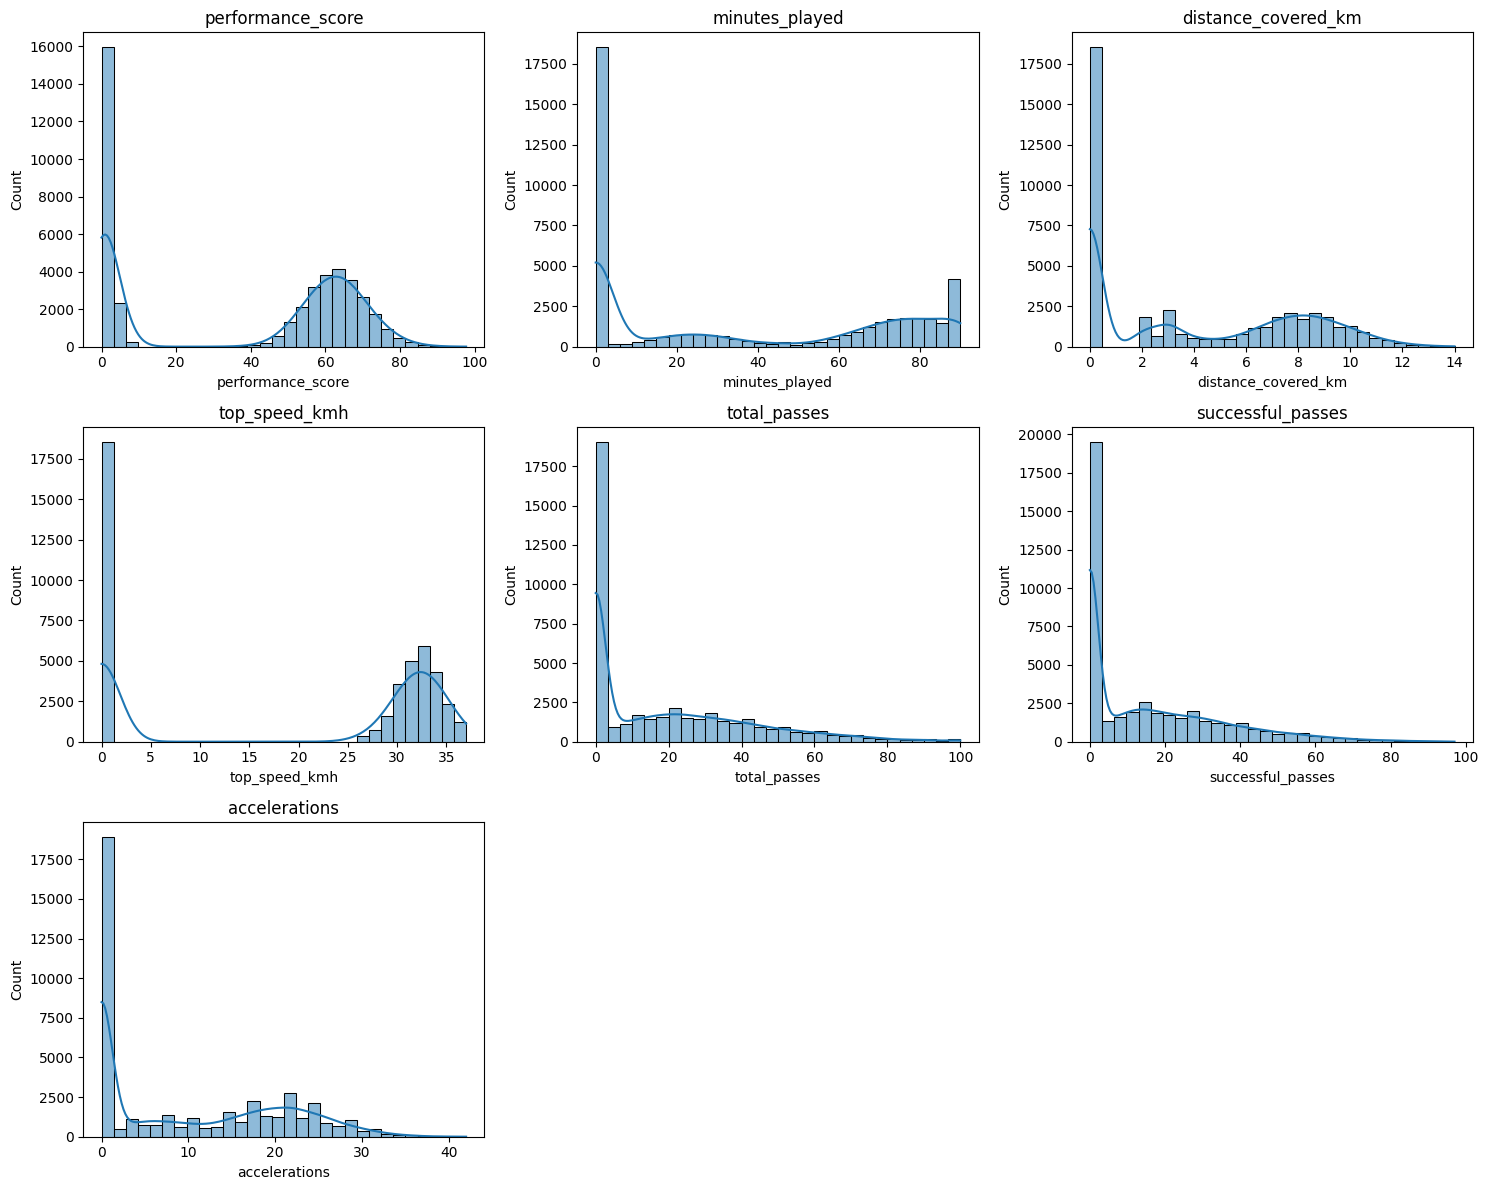

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(train[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Feature Distribution

Several numerical features exhibit right-skewed distributions. This behavior is expected for football performance statistics, where many players record low values while a small number of players achieve exceptionally high values.

Since these distributions reflect the natural characteristics of the data and tree-based ensemble models are robust to skewed features, no transformation will be applied during the initial preprocessing stage.

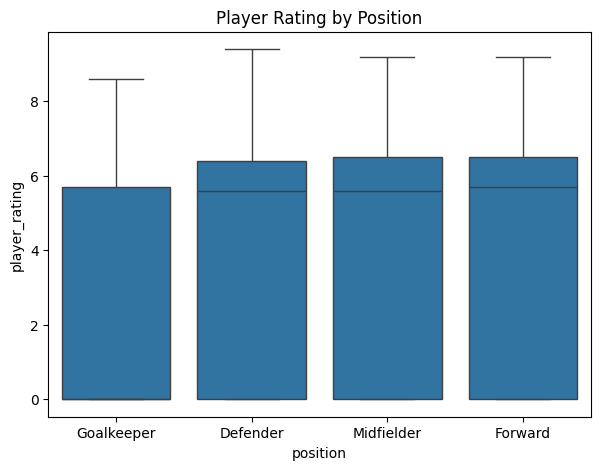

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train,
    x="position",
    y="player_rating"
)

plt.title("Player Rating by Position")

plt.show()

### Player Rating by Position

The distribution of player ratings was compared across the four playing positions.

The boxplot shows that goalkeepers tend to have slightly lower median ratings than the other positions. However, defenders, midfielders, and forwards exhibit very similar rating distributions with substantial overlap.

Overall, player position appears to have only a moderate influence on player ratings, suggesting that individual match performance statistics contribute more to the final rating than the player's position alone.

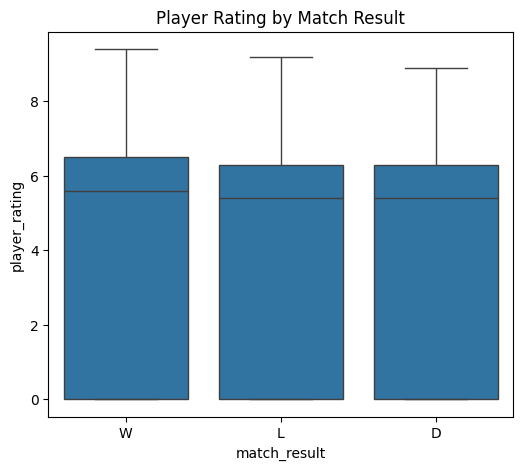

In [22]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=train,
    x="match_result",
    y="player_rating"
)

plt.title("Player Rating by Match Result")

plt.show()

In [23]:
cat_col = train.select_dtypes(include="O")
cat_col.nunique()

Id                  43584
player_id             998
player_name           995
nationality            48
team                   48
position                4
preferred_foot          2
club_name             122
match_id             1050
match_date             51
stadium                16
city                   16
opponent_team          48
tournament_stage        7
match_result            3
dtype: int64

In [24]:
pd.crosstab(train["nationality"], train["team"]).head()

team,Algeria,Argentina,Australia,Austria,Belgium,Brazil,Cameroon,Canada,Chile,Colombia,...,South Korea,Spain,Sweden,Switzerland,Tunisia,Turkey,Ukraine,United States,Uruguay,Uzbekistan
nationality,,,,,,,,,,,,,,,,,,,,,
Algerian,861,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
American,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,722,0,0
Argentine,0,850,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Australian,0,0,1034,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Austrian,0,0,0,693,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Relationship Between `team` and `nationality`

A cross-tabulation was performed to examine the relationship between the `team` and `nationality` features.

The analysis showed a one-to-one correspondence between the two variables, where each nationality is associated with exactly one national team. Therefore, both features contain the same information.

To avoid redundant information and reduce feature duplication, only one of these variables will be retained during preprocessing.

In [25]:
pd.crosstab(train["stadium"], train["city"]).head()

city,Atlanta,Boston,Dallas,East Rutherford,Guadalajara,Houston,Kansas City,Los Angeles,Mexico City,Miami,Monterrey,Philadelphia,San Francisco,Seattle,Toronto,Vancouver
stadium,,,,,,,,,,,,,,,,
AT&T Stadium,0,0,2752,0,0,0,0,0,0,0,0,0,0,0,0,0
Arrowhead Stadium,0,0,0,0,0,0,2862,0,0,0,0,0,0,0,0,0
BC Place,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3018
BMO Field,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2526,0
Estadio Akron,0,0,0,0,3042,0,0,0,0,0,0,0,0,0,0,0


### Relationship Between `stadium` and `city`

A cross-tabulation was performed to investigate the relationship between `stadium` and `city`.

The analysis revealed a one-to-one correspondence between the two variables, where each stadium is located in exactly one city. Consequently, both variables provide the same information.

To reduce feature redundancy, only one of these variables will be retained during preprocessing.

In [26]:
train["match_date"] = pd.to_datetime(train["match_date"])

In [27]:
train["month"] = train["match_date"].dt.month
train["day"] = train["match_date"].dt.day
train["day_of_week"] = train["match_date"].dt.day_name()

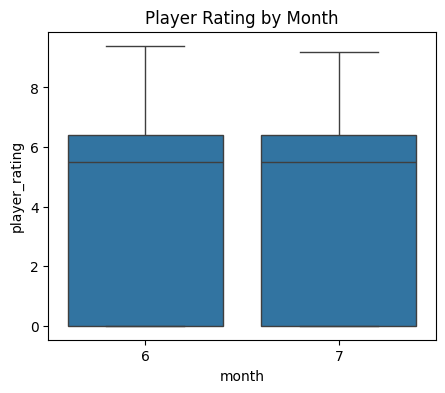

In [28]:
plt.figure(figsize=(5,4))

sns.boxplot(
    data=train,
    x="month",
    y="player_rating"
)

plt.title("Player Rating by Month")
plt.show()


The match_date feature was explored by extracting temporal components (month) and comparing their relationship with the target variable. No significant differences in player ratings were observed across the available time periods. Since the tournament spans only a short duration, the date itself is unlikely to provide predictive information.

In [29]:
train.drop(columns=["month","day_of_week","day"], inplace=True)

In [30]:
train.select_dtypes(include="object").columns

Index(['Id', 'player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'stadium', 'city',
       'opponent_team', 'tournament_stage', 'match_result'],
      dtype='object')

In [31]:
corr = train.corr(numeric_only=True)["player_rating"].sort_values(ascending=False)

corr

player_rating               1.000000
performance_score           0.996661
top_speed_kmh               0.979691
distance_covered_km         0.837534
minutes_played              0.837339
sprint_distance_km          0.821266
accelerations               0.799028
decelerations               0.794962
total_passes                0.745521
successful_passes           0.726532
possession_impact           0.623876
recoveries                  0.604887
defensive_actions           0.567453
stamina_score               0.557274
aerial_duels_won            0.535284
tackles                     0.503513
interceptions               0.466071
dribbles_attempted          0.462979
fouls_committed             0.448107
key_passes                  0.447832
clearances                  0.439657
crosses                     0.436741
aerial_duels_lost           0.428459
shots                       0.419941
fouls_suffered              0.419178
blocks                      0.340418
successful_dribbles         0.301617
t

In [32]:
corr = train.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

high_corr[high_corr > 0.95]

player_rating        performance_score      0.996661
successful_passes    total_passes           0.994782
top_speed_kmh        player_rating          0.979691
minutes_played       distance_covered_km    0.977372
top_speed_kmh        performance_score      0.975748
distance_covered_km  sprint_distance_km     0.969368
minutes_played       accelerations          0.954362
dtype: float64

In [33]:
train.loc[train["minutes_played"] == 0, "player_rating"].value_counts()

player_rating
0.0    18524
Name: count, dtype: int64

In [34]:
train.loc[train["minutes_played"] > 0, "player_rating"].value_counts().head()

player_rating
6.3    1405
6.2    1352
6.4    1346
6.1    1319
6.5    1275
Name: count, dtype: int64

In [35]:
train["goals_per90"] = train["goals"] * 90 / (train["minutes_played"] + 1)
test["goals_per90"] = test["goals"] * 90 / (test["minutes_played"] + 1)

In [36]:
train["assists_per90"] = train["assists"] * 90 / (train["minutes_played"] + 1)
test["assists_per90"] = test["assists"] * 90 / (test["minutes_played"] + 1)

In [37]:
train["distance_per_min"] = train["distance_covered_km"] / (train["minutes_played"] + 1)
test["distance_per_min"] = test["distance_covered_km"] / (test["minutes_played"] + 1)

In [38]:
train["passes_per_min"] = train["total_passes"] / (train["minutes_played"] + 1)
test["passes_per_min"] = test["total_passes"] / (test["minutes_played"] + 1)

In [39]:
train["def_actions_per_min"] = train["defensive_actions"] / (train["minutes_played"] + 1)
test["def_actions_per_min"] = test["defensive_actions"] / (test["minutes_played"] + 1)

In [40]:
new_features = [
    "goals_per90",
    "assists_per90",
    "distance_per_min",
    "passes_per_min",
    'def_actions_per_min'

]

train[new_features + ["player_rating"]].corr()["player_rating"].sort_values(ascending=False)

player_rating          1.000000
distance_per_min       0.880292
passes_per_min         0.840757
def_actions_per_min    0.598454
goals_per90            0.189315
assists_per90          0.002675
Name: player_rating, dtype: float64

In [41]:
train[[
    "goals",
    "goals_per90",
    "minutes_played",
    "distance_covered_km",
    "distance_per_min",
    "total_passes",
    "passes_per_min",
    'def_actions_per_min',
    'defensive_actions'

]].corr()

,goals,goals_per90,minutes_played,distance_covered_km,distance_per_min,total_passes,passes_per_min,def_actions_per_min,defensive_actions
goals,1.000000,0.842552,0.219974,0.221239,0.154148,0.179454,0.146563,0.004215,0.028443
goals_per90,0.842552,1.000000,0.137484,0.141873,0.149671,0.110946,0.127081,0.001262,0.002444
minutes_played,0.219974,0.137484,1.000000,0.977372,0.667490,0.849132,0.695601,0.520321,0.678805
distance_covered_km,0.221239,0.141873,0.977372,1.000000,0.725754,0.850425,0.715384,0.513048,0.657833
distance_per_min,0.154148,0.149671,0.667490,0.725754,1.000000,0.588803,0.752269,0.533601,0.450228
total_passes,0.179454,0.110946,0.849132,0.850425,0.588803,1.000000,0.870538,0.530887,0.673724
passes_per_min,0.146563,0.127081,0.695601,0.715384,0.752269,0.870538,1.000000,0.594347,0.567921
def_actions_per_min,0.004215,0.001262,0.520321,0.513048,0.533601,0.530887,0.594347,1.000000,0.871750
defensive_actions,0.028443,0.002444,0.678805,0.657833,0.450228,0.673724,0.567921,0.871750,1.000000


In [42]:
cols_to_drop = [
    "goals_per90",
    "assists_per90",

]

train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

# Preprocessing

In [43]:
drop_cols = [
    "Id",
    "player_id",
    "player_name",
    "nationality",
    "city",
    "match_id",
    "match_date",
    "performance_score"
]
test_ids = test["Id"].copy()
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [44]:
X = train.drop(columns=["player_rating"])
y = train["player_rating"]

In [45]:

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", len(numerical_features))

Categorical: ['team', 'position', 'preferred_foot', 'club_name', 'stadium', 'opponent_team', 'tournament_stage', 'match_result']
Numerical: 61


In [47]:
onehot_features = [
    "position",
    "preferred_foot",
    "tournament_stage",
    "match_result",
    "stadium"
]

target_features = [
    "team",
    "opponent_team",
    "club_name"
]

numeric_features = [
    col for col in X_train.columns
    if col not in onehot_features + target_features
]


# Encoding Strategy

Low-cardinality categorical features (position, preferred_foot, match_result, tournament_stage, stadium) were encoded using One-Hot Encoding.
High-cardinality features (team, opponent_team, club_name) were encoded using Target Encoding to avoid creating a large number of sparse features while preserving useful target-related information.



In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            onehot_features
        ),
        (
            "target",
            TargetEncoder(),
            target_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_valid, y_train, y_valid):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)

    train_mse = mean_squared_error(y_train, train_pred)
    valid_mse = mean_squared_error(y_valid, valid_pred)

    train_rmse = np.sqrt(train_mse)
    valid_rmse = np.sqrt(valid_mse)

    train_r2 = r2_score(y_train, train_pred)
    valid_r2 = r2_score(y_valid, valid_pred)

    print(f"Train MSE : {train_mse:.5f}")
    print(f"Valid MSE : {valid_mse:.5f}")
    print(f"Train RMSE: {train_rmse:.5f}")
    print(f"Valid RMSE: {valid_rmse:.5f}")
    print(f"Train R²  : {train_r2:.5f}")
    print(f"Valid R²  : {valid_r2:.5f}")

In [50]:
from lightgbm import LGBMRegressor

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
))
])
evaluate_model(lgbm_pipeline,X_train, X_valid,y_train, y_valid)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4835
[LightGBM] [Info] Number of data points in the train set: 34867, number of used features: 96
[LightGBM] [Info] Start training from score 3.619247
Train MSE : 0.12155
Valid MSE : 0.21878
Train RMSE: 0.34864
Valid RMSE: 0.46774
Train R²  : 0.98787
Valid R²  : 0.97808


In [54]:
lgbm_pipeline.fit(X_train, y_train)

valid_pred = lgbm_pipeline.predict(X_valid)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4835
[LightGBM] [Info] Number of data points in the train set: 34867, number of used features: 96
[LightGBM] [Info] Start training from score 3.619247


In [51]:

from catboost import CatBoostRegressor

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


# CatBoost
# --------------------
catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0,
    cat_features=cat_features
)
evaluate_model(catboost_model,X_train, X_valid,y_train, y_valid)



Train MSE : 0.19270
Valid MSE : 0.21532
Train RMSE: 0.43898
Valid RMSE: 0.46403
Train R²  : 0.98077
Valid R²  : 0.97843


In [52]:
# Combine train + validation data
X_full = pd.concat([X_train, X_valid], axis=0)
y_full = pd.concat([y_train, y_valid], axis=0)


# Train final models
lgbm_pipeline.fit(X_full, y_full)

catboost_model.fit(X_full, y_full)


# Predictions on test
lgb_test_pred = lgbm_pipeline.predict(test)
cat_test_pred = catboost_model.predict(test)


# Ensemble prediction
final_test_pred = 0.5 * lgb_test_pred + 0.5 * cat_test_pred




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 43584, number of used features: 96
[LightGBM] [Info] Start training from score 3.622476


In [53]:
# # Create submission
# submission = pd.DataFrame({
#     "Id": test_ids,
#     "player_rating": final_test_pred
# })


# submission.to_csv("submission12.csv", index=False)

# submission.head()

# analysis

In [55]:
analysis = X_valid.copy()

analysis["true"] = y_valid.values
analysis["pred"] = valid_pred
analysis["error"] = np.abs(analysis["true"] - analysis["pred"])
analysis["signed_error"] = analysis["pred"] - analysis["true"]

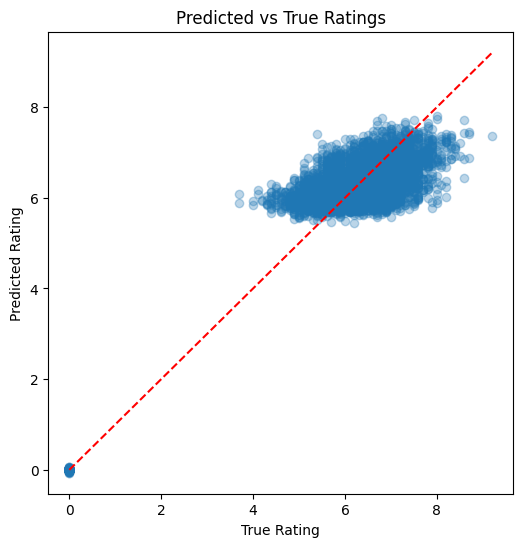

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(
    analysis["true"],
    analysis["pred"],
    alpha=0.3
)

plt.plot(
    [analysis["true"].min(), analysis["true"].max()],
    [analysis["true"].min(), analysis["true"].max()],
    "r--"
)

plt.xlabel("True Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs True Ratings")
plt.show()

## Error Analysis

The validation predictions showed a clear regression-to-the-mean behavior.

- Players with low ratings were generally predicted higher than their true ratings.
- Players with high ratings were generally predicted lower than their true ratings.

This is expected in regression models because the model minimizes the overall squared error by producing predictions closer to the center of the target distribution.

The largest prediction errors occurred at the extremes of the rating range, while predictions around the average ratings achieved much lower errors.

This analysis motivated the feature engineering step, where additional normalized features were introduced to better distinguish exceptional player performances.

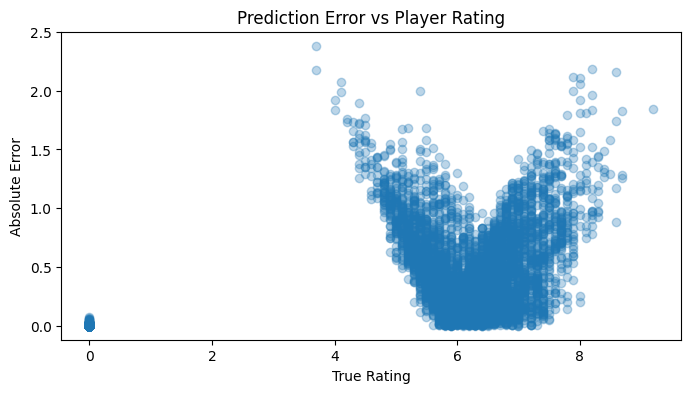

In [57]:
plt.figure(figsize=(8,4))

plt.scatter(
    analysis["true"],
    analysis["error"],
    alpha=0.3
)

plt.xlabel("True Rating")
plt.ylabel("Absolute Error")
plt.title("Prediction Error vs Player Rating")

plt.show()

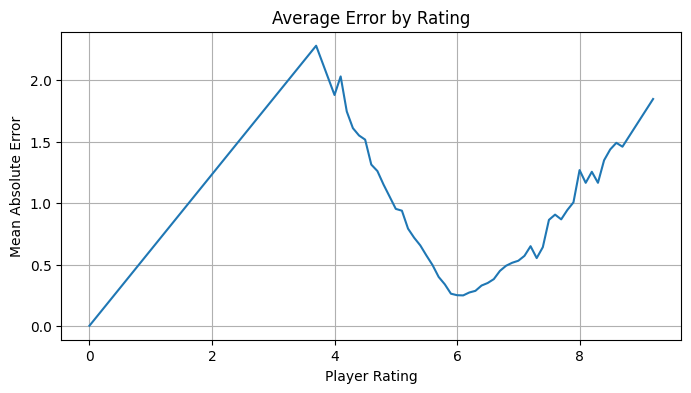

In [63]:
analysis.groupby(
    analysis["true"].round(1)
)["error"].mean().plot(figsize=(8,4))

plt.ylabel("Mean Absolute Error")
plt.xlabel("Player Rating")
plt.title("Average Error by Rating")

plt.grid(True)
plt.show()

In [61]:
hard = analysis.nlargest(200,"error")
easy = analysis.nsmallest(200,"error")

In [62]:
comparison = pd.DataFrame({
    "Hard": hard.mean(numeric_only=True),
    "Easy": easy.mean(numeric_only=True)
})

comparison["Difference"] = comparison["Hard"] - comparison["Easy"]

comparison.sort_values("Difference", key=np.abs, ascending=False)

,Hard,Easy,Difference
market_value_eur,1.987463e+07,1.943821e+07,436425.4100
minutes_played,6.274500e+01,1.200000e-01,62.6250
total_minutes_tournament,2.871500e+02,2.397350e+02,47.4150
total_passes,3.339000e+01,6.000000e-02,33.3300
top_speed_kmh,3.204100e+01,1.605000e-01,31.8805
...,...,...,...
goals_opponent,1.330000e+00,1.310000e+00,0.0200
clean_sheet,2.000000e-02,0.000000e+00,0.0200
penalty_saves,0.000000e+00,1.500000e-02,-0.0150
pass_accuracy,8.096000e-01,7.965000e-01,0.0131


## Feature Engineering

After analyzing the validation errors, we observed that the model struggled with players who had very different playing times.

Using raw cumulative statistics (such as total passes, total distance covered, and defensive actions) introduced bias because players who played more minutes naturally accumulated larger values.

To make these features more comparable across players, we created normalized per-minute features:

- `distance_per_min`
- `passes_per_min`
- `def_actions_per_min`

These features measure player efficiency rather than total volume of actions, allowing the model to compare players with different playing times more fairly.

This decision was driven by the error analysis, which showed that many high-error samples were associated with unusual playing-time patterns.